In [4]:
import os
import json
import datetime
os.chdir('/home/benjaminb/Dokumente/JKU/Semester_9/Practical_Work')
from utils.mri_dataloader import MRI_Dataloader

mdl = MRI_Dataloader()

In [5]:
with open("experiments/05_data_visualizer/validation_lesions.json") as f:
    validation_lesions = json.load(f)

In [6]:
validation_lesions

[{'idx': '1',
  'Patient': 'YG_NRSFSRTTONBY',
  'Lesion': '3',
  'n_scans': '21',
  'interpolation': '6'},
 {'idx': '2',
  'Patient': 'YG_NRSFSRTTONBY',
  'Lesion': '1',
  'n_scans': '10',
  'interpolation': '6'},
 {'idx': '3',
  'Patient': 'YG_DFS01ZHF1G5R',
  'Lesion': '2',
  'n_scans': '12',
  'interpolation': '7'},
 {'idx': '4',
  'Patient': 'YG_DDHY5HW3GJIP',
  'Lesion': '2',
  'n_scans': '11',
  'interpolation': '3'},
 {'idx': '5',
  'Patient': 'YG_UEM7VTVQNC1M',
  'Lesion': '3',
  'n_scans': '10',
  'interpolation': '5'},
 {'idx': '6',
  'Patient': 'YG_R4Z3IXHG01L2',
  'Lesion': '1',
  'n_scans': '10',
  'interpolation': '2'},
 {'idx': '7',
  'Patient': 'YG_Q1FS2D6EVG3E',
  'Lesion': '9',
  'n_scans': '10',
  'interpolation': '5'},
 {'idx': '8',
  'Patient': 'YG_MTO9K0JU7M07',
  'Lesion': '11',
  'n_scans': '9',
  'interpolation': '4'},
 {'idx': '9',
  'Patient': 'YG_04YGLO8ATWRL',
  'Lesion': '2',
  'n_scans': '6',
  'interpolation': '4'},
 {'idx': '10',
  'Patient': 'YG_3I6CQJ

In [7]:
date_convert = lambda x: datetime.datetime.strptime(x, "%Y-%m-%d")

max_time = 180
last_scan_windows = {}

for i in range(len(validation_lesions)):
    patient_id = validation_lesions[i]["Patient"]
    scan_id = validation_lesions[i]["Lesion"]
    trj = mdl.find_lesion_trajectory(patient_id, scan_id)
    patient_id +=  "_" + str(i)
    last_scan_windows[patient_id] = []

    first_scan = trj.dates[0]
    last_scan = trj.dates[-1]
    last_scan_windows[patient_id].append(0)
    
    for j_date in reversed(trj.dates[:-1]):
        delta = (date_convert(last_scan) - date_convert(j_date)).days
        if delta > max_time: break
        last_scan_windows[patient_id].append(delta)   

for key, value in last_scan_windows.items():
    print(key)
    print(value)
    print("-----")



YG_NRSFSRTTONBY_0
[0, 79, 166]
-----
YG_NRSFSRTTONBY_1
[0, 106, 148]
-----
YG_DFS01ZHF1G5R_2
[0, 118]
-----
YG_DDHY5HW3GJIP_3
[0, 57, 113, 168]
-----
YG_UEM7VTVQNC1M_4
[0, 112]
-----
YG_R4Z3IXHG01L2_5
[0]
-----
YG_Q1FS2D6EVG3E_6
[0, 62, 140]
-----
YG_MTO9K0JU7M07_7
[0]
-----
YG_04YGLO8ATWRL_8
[0]
-----
YG_3I6CQJCTAUAS_9
[0, 105, 148]
-----
YG_85UM3OTXRUXH_10
[0]
-----
YG_8HW12P6TPDBB_11
[0, 98, 155]
-----
YG_85UM3OTXRUXH_12
[0, 155]
-----
YG_H19ZB9NMLHLJ_13
[0, 74, 113]
-----
YG_BSZ8HDFDH8G9_14
[0, 42, 68, 85, 161]
-----
YG_B3IQ5SB5YX54_15
[0]
-----
YG_DDHY5HW3GJIP_16
[0, 57, 113, 168]
-----
YG_K5SXG4URBIX0_17
[0]
-----
YG_69FMUN9PHHKE_18
[0, 50, 119]
-----
YG_0Y74OO0HCJZA_19
[0, 58, 94]
-----


In [29]:
with open("experiments/05_data_visualizer/validation_lesions.json", "r") as f:
    validation_lesions = json.load(f)

for item in validation_lesions:
    T_minus = last_scan_windows[item["Patient"] + "_" + str(validation_lesions.index(item))]
    item["extrapolation_T_minus"] = list(reversed(T_minus))

    trj = mdl.find_lesion_trajectory(item["Patient"], item["Lesion"])
    trj.extract_growth_phase()
    item["extrapolation_dates"] = trj.allowed_dates[-len(T_minus):]

    item["extrapolation_indices"] = list(range(len(trj.allowed_dates)))[-len(T_minus):]


with open("experiments/05_data_visualizer/validation_lesions.json", "w") as f:
    json.dump(validation_lesions, f, indent=4)

In [55]:
def flatten(xss):
    return [x for xs in xss for x in xs]

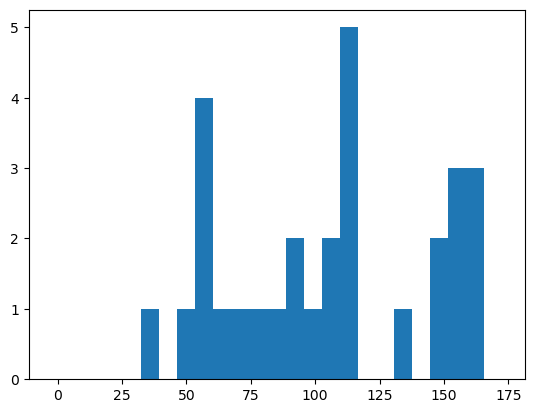

In [61]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.hist(flatten([v for v in last_scan_windows.values()]), bins=range(1, max_time, 7), align='left')#

plt.show()

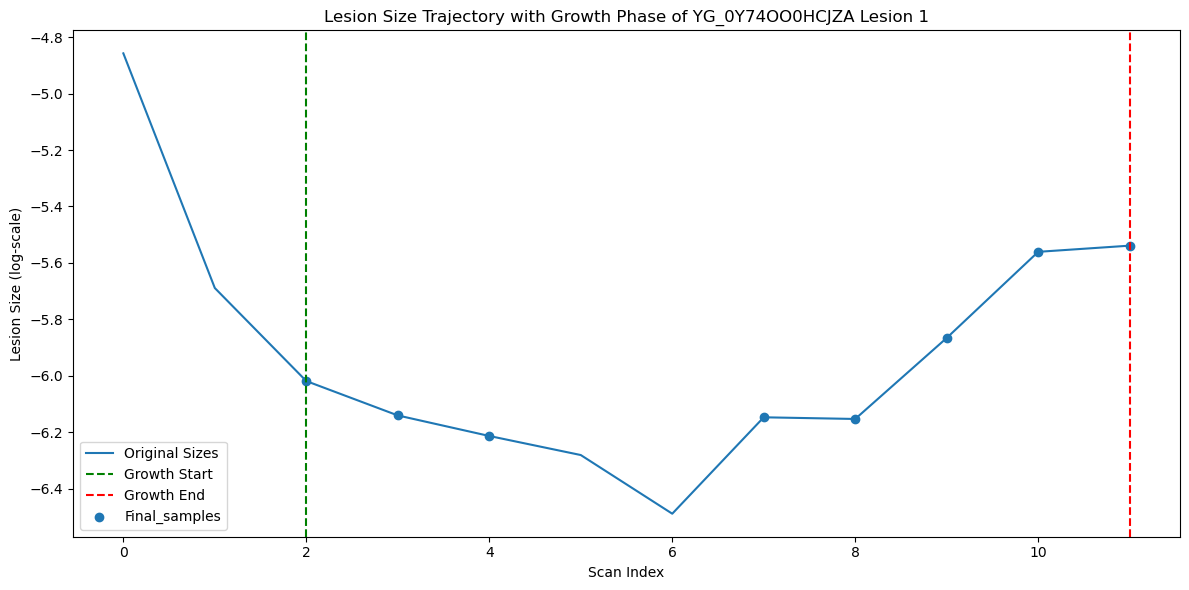

In [65]:
trj.plot_growth_phase()

In [82]:
trj = mdl.find_lesion_trajectory("YG_I21ELPTXJUMO", "9")

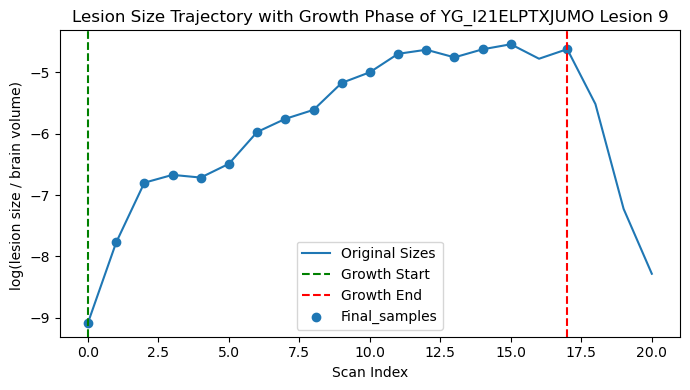

In [87]:
data = trj.extract_growth_phase(log_scale=True, tolerance=0.15)
plt.figure(figsize=(7, 4))
plt.plot(trj.sizes, label='Original Sizes')
plt.axvline(data[0], color='g', linestyle='--', label='Growth Start')
plt.axvline(data[1], color='r', linestyle='--', label='Growth End')
plt.scatter(data[2], trj.sizes[data[2]], label='Final_samples')
plt.legend()
plt.title(f'Lesion Size Trajectory with Growth Phase of {trj.patient_id} Lesion {trj.label_id}')
plt.xlabel('Scan Index')
plt.ylabel('log(lesion size / brain volume) ')
plt.tight_layout()
plt.show()